# RGCN: графовые нейронные сети с типами отношений.

Автор задач: Пасканов В.Д. 

Цель семинара: изучить архитектуру Relational Graph Convolutional Network (RGCN) и сравнить ее поведение на toy-графе и реальном реляционном графе из `torch_geometric`.

Материалы:
* Schlichtkrull et al. "Modeling Relational Data with Graph Convolutional Networks" (ESWC 2018)
* Документация PyTorch Geometric:
    * https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.RGCNConv.html
    * https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.Entities.html
    * https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html
* Документация PyTorch:
    * https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
    * https://pytorch.org/docs/stable/optim.html

## Вопросы для совместного обсуждения

1\. Обсудите различия между GCN и RGCN. Почему учет типов отношений критичен для графов знаний?

2\. Какие проблемы возникают при большом числе типов ребер в RGCN и как помогают basis-decomposition и block-decomposition?

3\. В чем разница между задачами node classification и link prediction в контексте реляционных графов?

## Задачи для самостоятельного решения

In [6]:
import time
import warnings
from typing import Tuple, List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import torch_geometric
from torch_geometric.datasets import Entities
from torch_geometric.nn import RGCNConv
from torch_geometric.data import Data

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")

PyTorch version: 2.11.0+cu128
PyG version: 2.7.0


<p class="task" id="1"></p>

1\. Подготовьте два графа для всех последующих заданий:

* `toy_graph`: вручную заданный граф знаний на 8-12 сущностей с 3-4 типами ребер;
* `real_graph`: один из реляционных датасетов `torch_geometric` (например, `Entities(root, name="AIFB")`).

Для каждого графа подготовьте `edge_index`, `edge_type`, признаки узлов `x`, метки `y` и train/val/test-разбиение (если в датасете нет `val`, сформируйте его из train).

Выведите размерности и число типов отношений для **обоих** графов.

- [ ] Проверено на семинаре

In [3]:
def create_toy_graph() -> Data:
    """
    Создает игрушечный реляционный граф.
    10 сущностей, 3 типа отношений, 2 класса для классификации.
    """
    num_nodes = 10
    num_relations = 3
    num_classes = 2
    feature_dim = 16
    
    edge_index = torch.tensor([
        [0, 1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 3, 6],
        [1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 0, 2, 6, 9]
    ], dtype=torch.long)
    
    edge_type = torch.tensor([0, 0, 1, 1, 2, 0, 1, 2, 0, 1, 2, 1, 2, 0], dtype=torch.long)
    
    x = torch.randn((num_nodes, feature_dim), dtype=torch.float)
    
    y = torch.randint(0, num_classes, (num_nodes,), dtype=torch.long)
    
    train_mask = torch.tensor([True]*6 + [False]*4)
    val_mask = torch.tensor([False]*6 + [True]*2 + [False]*2)
    test_mask = torch.tensor([False]*8 + [True]*2)
    
    return Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y,
                train_mask=train_mask, val_mask=val_mask, test_mask=test_mask,
                num_relations=num_relations, num_classes=num_classes)

def load_real_graph() -> Data:
    dataset = Entities(root='./data/Entities', name='AIFB')
    data = dataset[0]
    
    num_nodes = data.num_nodes
    y = torch.full((num_nodes,), -1, dtype=torch.long) # -1 для узлов без меток
    
    y[data.train_idx] = data.train_y
    y[data.test_idx] = data.test_y
    
    train_idx_arr = data.train_idx.numpy()
    train_y_arr = data.train_y.numpy()
    
    tr_idx, val_idx, _, _ = train_test_split(train_idx_arr, train_y_arr, test_size=0.2, random_state=42, stratify=train_y_arr)
    
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    
    train_mask[torch.tensor(tr_idx)] = True
    val_mask[torch.tensor(val_idx)] = True
    test_mask[data.test_idx] = True

    x = torch.eye(num_nodes, dtype=torch.float)
    
    return Data(x=x, edge_index=data.edge_index, edge_type=data.edge_type, y=y,
                train_mask=train_mask, val_mask=val_mask, test_mask=test_mask,
                num_relations=dataset.num_relations, num_classes=dataset.num_classes)

toy_graph = create_toy_graph()
real_graph = load_real_graph()

print("--- Toy Graph ---")
print(f"Nodes: {toy_graph.num_nodes}, Features: {toy_graph.x.shape[1]}")
print(f"Edges: {toy_graph.edge_index.shape[1]}, Relations: {toy_graph.num_relations}")
print(f"Classes: {toy_graph.num_classes}\n")

print("--- Real Graph (AIFB) ---")
print(f"Nodes: {real_graph.num_nodes}, Features: {real_graph.x.shape[1]}")
print(f"Edges: {real_graph.edge_index.shape[1]}, Relations: {real_graph.num_relations}")
print(f"Classes: {real_graph.num_classes}")

Extracting data\Entities\aifb.tgz
Processing...


--- Toy Graph ---
Nodes: 10, Features: 16
Edges: 14, Relations: 3
Classes: 2

--- Real Graph (AIFB) ---
Nodes: 8285, Features: 8285
Edges: 58086, Relations: 90
Classes: 4


Done!


<p class="task" id="2"></p>

2\. Реализуйте класс двухслойной модели `RGCN` на базе `torch_geometric.nn.RGCNConv`.

Требования:
* первый слой: `in_channels -> hidden_channels`;
* второй слой: `hidden_channels -> num_classes`;
* между слоями используйте `ReLU` и `Dropout`.

Сделайте прямой проход `model(x, edge_index, edge_type)` **отдельно для `toy_graph` и `real_graph`**. Для каждого случая выведите размерность логитов и покажите, что она равна `(num_nodes, num_classes)`.

- [ ] Проверено на семинаре

In [4]:
class RGCNModel(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int, 
                 num_relations: int, num_bases: Optional[int] = None, dropout_p: float = 0.5):
        """
        Двухслойная RGCN сеть.
        """
        super().__init__()
        self.dropout_p = dropout_p
        
        self.conv1 = RGCNConv(in_channels, hidden_channels, num_relations, num_bases=num_bases)
        self.conv2 = RGCNConv(hidden_channels, num_classes, num_relations, num_bases=num_bases)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_type: torch.Tensor) -> torch.Tensor:
        """
        x: [num_nodes, in_channels]
        edge_index: [2, num_edges]
        edge_type: [num_edges]
        Returns: [num_nodes, num_classes]
        """
        h = self.conv1(x, edge_index, edge_type)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout_p, training=self.training)
        
        out = self.conv2(h, edge_index, edge_type)
        return out

hidden_dim = 16

toy_model = RGCNModel(toy_graph.x.shape[1], hidden_dim, toy_graph.num_classes, toy_graph.num_relations)
real_model = RGCNModel(real_graph.x.shape[1], hidden_dim, real_graph.num_classes, real_graph.num_relations)

toy_out = toy_model(toy_graph.x, toy_graph.edge_index, toy_graph.edge_type)
real_out = real_model(real_graph.x, real_graph.edge_index, real_graph.edge_type)

print(f"Toy Model Output Shape: {toy_out.shape} | Expected: ({toy_graph.num_nodes}, {toy_graph.num_classes})")
print(f"Real Model Output Shape: {real_out.shape} | Expected: ({real_graph.num_nodes}, {real_graph.num_classes})")

assert toy_out.shape == (toy_graph.num_nodes, toy_graph.num_classes)
assert real_out.shape == (real_graph.num_nodes, real_graph.num_classes)

Toy Model Output Shape: torch.Size([10, 2]) | Expected: (10, 2)
Real Model Output Shape: torch.Size([8285, 4]) | Expected: (8285, 4)


<p class="task" id="3"></p>

3\. Обучите модель RGCN для классификации узлов на train-разбиении.

Выполните для `toy_graph` и `real_graph`:
* выбор функции потерь `CrossEntropyLoss`;
* настройку оптимизатора (`Adam`);
* цикл обучения на 100-300 эпох.

Каждые 20 эпох выводите `loss` и `train accuracy`. Постройте два графика изменения `loss` по эпохам и сравните динамику обучения.

- [ ] Проверено на семинаре

--- Обучение Toy Graph ---


 12%|█▏        | 12/100 [00:00<00:00, 118.79it/s]

Epoch 020 | Loss: 0.0804 | Train Acc: 1.0000


 80%|████████  | 80/100 [00:00<00:00, 294.59it/s]

Epoch 040 | Loss: 0.0059 | Train Acc: 1.0000
Epoch 060 | Loss: 0.0018 | Train Acc: 1.0000
Epoch 080 | Loss: 0.0018 | Train Acc: 1.0000


...

Epoch 060 | Loss: 0.0040 | Train Acc: 1.0000


 80%|████████  | 80/100 [23:00<05:34, 16.73s/it]

Epoch 080 | Loss: 0.0037 | Train Acc: 1.0000


100%|██████████| 100/100 [28:27<00:00, 17.08s/it]

Epoch 100 | Loss: 0.0058 | Train Acc: 1.0000


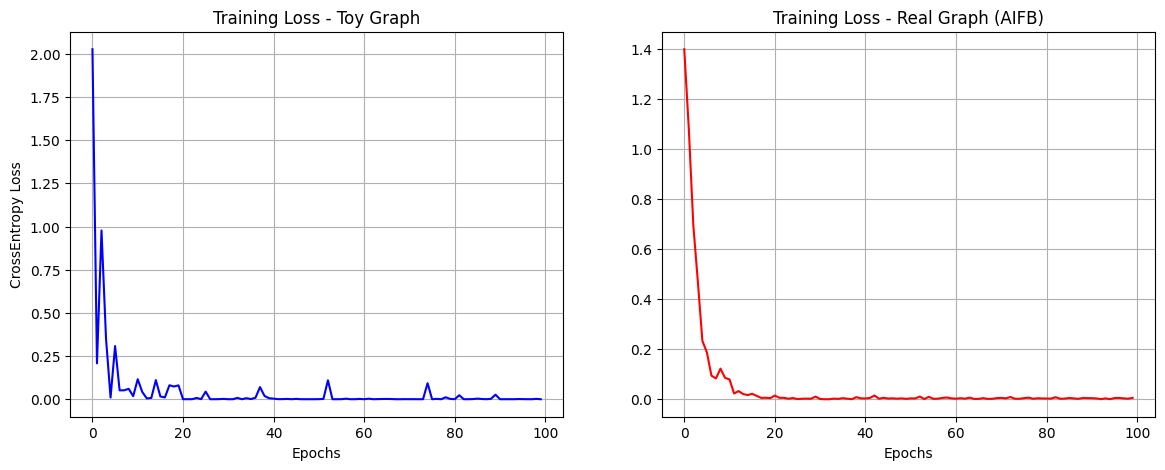

In [7]:
def train_node_classification(model: nn.Module, data: Data, epochs: int = 100, lr: float = 0.01) -> Tuple[List[float], List[float]]:
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []
    acc_history = []
    
    model.train()
    for epoch in tqdm(range(epochs)):
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index, data.edge_type)
        
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        
        loss.backward()
        optimizer.step()
        
        preds = out[data.train_mask].argmax(dim=1)
        acc = accuracy_score(data.y[data.train_mask].cpu(), preds.cpu())
        
        loss_history.append(loss.item())
        acc_history.append(acc)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f} | Train Acc: {acc:.4f}")
            
    return loss_history, acc_history

print("--- Обучение Toy Graph ---")
toy_model = RGCNModel(toy_graph.x.shape[1], 16, toy_graph.num_classes, toy_graph.num_relations)
toy_losses, toy_accs = train_node_classification(toy_model, toy_graph, epochs=100)

print("\n--- Обучение Real Graph (AIFB) ---")
real_model = RGCNModel(real_graph.x.shape[1], 16, real_graph.num_classes, real_graph.num_relations, num_bases=20)
real_losses, real_accs = train_node_classification(real_model, real_graph, epochs=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(toy_losses, label='Toy Graph', color='blue')
ax1.set_title('Training Loss - Toy Graph')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('CrossEntropy Loss')
ax1.grid(True)

ax2.plot(real_losses, label='Real Graph', color='red')
ax2.set_title('Training Loss - Real Graph (AIFB)')
ax2.set_xlabel('Epochs')
ax2.grid(True)

plt.show()

<p class="task" id="4"></p>

4\. Оцените модель на валидационной и тестовой выборках.

Сделайте это для `toy_graph` и `real_graph`, выведите:
* `val accuracy` и `test accuracy`;
* confusion matrix для тестовой выборки;
* список узлов, для которых модель ошиблась.

Сравните, на каком графе модель работает стабильнее, и кратко объясните почему.

- [ ] Проверено на семинаре

--- Результаты для Toy Graph ---
Val Accuracy:  0.5000
Test Accuracy: 1.0000


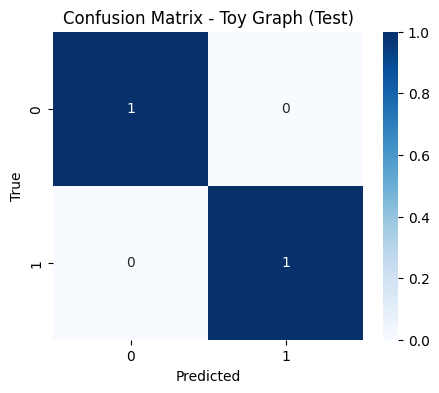

Узлы с ошибками (глобальные индексы): []

--- Результаты для Real Graph (AIFB) ---
Val Accuracy:  0.9286
Test Accuracy: 0.8889


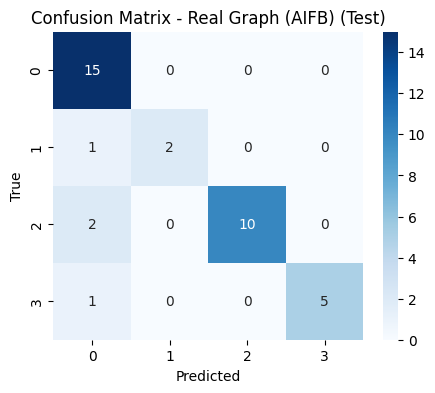

Узлы с ошибками (глобальные индексы): [36, 2344, 3065, 7089]



In [8]:
@torch.no_grad()
def evaluate_model(model: nn.Module, data: Data, graph_name: str):
    model.eval()
    out = model(data.x, data.edge_index, data.edge_type)
    
    val_preds = out[data.val_mask].argmax(dim=1).cpu()
    test_preds = out[data.test_mask].argmax(dim=1).cpu()
    
    # Истинные метки
    val_true = data.y[data.val_mask].cpu()
    test_true = data.y[data.test_mask].cpu()
    
    val_acc = accuracy_score(val_true, val_preds)
    test_acc = accuracy_score(test_true, test_preds)
    
    print(f"--- Результаты для {graph_name} ---")
    print(f"Val Accuracy:  {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    cm = confusion_matrix(test_true, test_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {graph_name} (Test)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    test_indices = torch.where(data.test_mask)[0].cpu().numpy()
    errors = test_preds != test_true
    misclassified_nodes = test_indices[errors.numpy()]
    
    print(f"Узлы с ошибками (глобальные индексы): {misclassified_nodes.tolist()}\n")

evaluate_model(toy_model, toy_graph, "Toy Graph")
evaluate_model(real_model, real_graph, "Real Graph (AIFB)")

<p class="task" id="5"></p>

5\. Проведите мини-эксперимент по влиянию числа базисов `num_bases` в `RGCNConv` (например: `None`, `2`, `4`).

Выполните эксперимент на **обоих** графах: `toy_graph` и `real_graph`.
Для каждого варианта зафиксируйте:
* число обучаемых параметров модели;
* финальную `test accuracy`;
* время обучения (приблизительно).

Сравните результаты между двумя графами и сделайте вывод о компромиссе между качеством и сложностью модели.

- [ ] Проверено на семинаре

In [10]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def run_bases_experiment(graph_data: Data, graph_name: str, bases_list: List[Optional[int]]):
    print(f"=== Эксперимент для {graph_name} ===")
    print(f"{'Bases':<10} | {'Params':<10} | {'Test Acc':<10} | {'Time (s)':<10}")
    print("-" * 45)
    
    for bases in bases_list:
        model = RGCNModel(in_channels=graph_data.x.shape[1], 
                          hidden_channels=16, 
                          num_classes=graph_data.num_classes, 
                          num_relations=graph_data.num_relations, 
                          num_bases=bases)
        
        params = count_parameters(model)
        
        start_time = time.time()
        optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        model.train()
        for _ in tqdm(range(30)):
            optimizer.zero_grad()
            out = model(graph_data.x, graph_data.edge_index, graph_data.edge_type)
            loss = F.cross_entropy(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
            loss.backward()
            optimizer.step()
        train_time = time.time() - start_time
        
        model.eval()
        with torch.no_grad():
            out = model(graph_data.x, graph_data.edge_index, graph_data.edge_type)
            preds = out[graph_data.test_mask].argmax(dim=1).cpu()
            true = graph_data.y[graph_data.test_mask].cpu()
            acc = accuracy_score(true, preds)
            
        b_str = str(bases) if bases is not None else "None"
        print(f"{b_str:<10} | {params:<10} | {acc:<10.4f} | {train_time:<10.4f}")
    print("\n")

bases_to_test = [None, 2, 4]

run_bases_experiment(toy_graph, "Toy Graph", bases_to_test)
run_bases_experiment(real_graph, "Real Graph (AIFB)", bases_to_test)

=== Эксперимент для Toy Graph ===
Bases      | Params     | Test Acc   | Time (s)  
---------------------------------------------


100%|██████████| 30/30 [00:00<00:00, 162.37it/s]


None       | 1170       | 0.5000     | 0.1895    


100%|██████████| 30/30 [00:00<00:00, 302.36it/s]


2          | 894        | 1.0000     | 0.1011    


...

None       | 12068804   | 0.9722     | 1841.5828 


100%|██████████| 30/30 [14:53<00:00, 29.78s/it]


2          | 398252     | 0.9722     | 893.4933  


100%|██████████| 30/30 [14:53<00:00, 29.77s/it]


4          | 663860     | 0.9722     | 893.0527  


